# Lab 10 — OOD / Drift / Failure Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab10_ood_drift_evaluation/notebook.ipynb)

**课程可靠性闭环实验。** 训练一个 world model 只是起点 —— 它在训练分布之外还可靠吗？
本 lab 在 ID（in-distribution）数据上训练一个 Lab 2 风格的 latent dynamics model，
然后系统性地制造 **distribution shift**（Mild / Strong OOD），沿四个层面评估失效模式：

> **one-step error → multi-step drift → uncertainty proxy → planning / policy failure**

最后自动生成一个 **Failure Gallery**（`assets/failure_gallery/`），把最典型的失败案例存档。

## 1. Motivation：为什么不能只看 one-step loss？

训练 world model 时最常报告的指标是 **one-step prediction error**。但真实部署时，模型做的事情完全不同：

- **Multi-step rollout**：预测被喂回模型自身，每步误差叠加（**compounding error / drift**）；
- **Planning / control**：planner 会主动"钻空子"，挑选模型误差最大的动作序列（**model exploitation**）；
- **OOD 环境**：真实世界的速度、摩擦、光照、遮挡随时偏离训练分布。

一个 one-step loss 很漂亮的模型，rollout 10 步后可能完全发散。本 lab 的核心教学点：

> **评估 world model 不能只看 one-step loss；drift、compounding error、OOD robustness 才是部署关键。**
> （对应 CIS6280 L23 的评估框架：accuracy → calibration → robustness → downstream utility。）

## 2. Setup

**Why this cell exists:** 依赖只有 PyTorch（CPU 足够）、NumPy、Matplotlib，Colab 已预装；本地缺失时自动安装。

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["torch", "matplotlib"]:
    ensure(pkg)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline
os.makedirs("assets/failure_gallery", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu")

torch 2.8.0 | device: cpu


## 3. Environment & Dataset：一个世界，三种物理

沿用 Lab 0/2 的 moving-ball world，但把物理与观测参数全部暴露出来。三种实验条件：

| 条件 | speed | friction | bounce | 像素噪声 | 背景 | 遮挡条 |
|---|---|---|---|---|---|---|
| **ID**（训练分布） | 1.0 | 0.95 | 0.9（弹性墙） | 无 | 纯黑 | 无 |
| **Mild OOD** | ×1.5 | 0.95 | 0.9 | 轻微 | 微亮 | 无 |
| **Strong OOD** | ×3.0 | **1.05（负阻尼，速度被放大）** | **0.15（反弹变粘滞）** | 强 | 灰底 | **静态遮挡条（训练从未见过）** |

**Why:** distribution shift 不需要换数据集 —— 同一段模拟器代码，换一组参数，就是最干净的受控 OOD 实验。

train (ID): (2000, 64, 64) | eval per condition: (640, 64, 64)


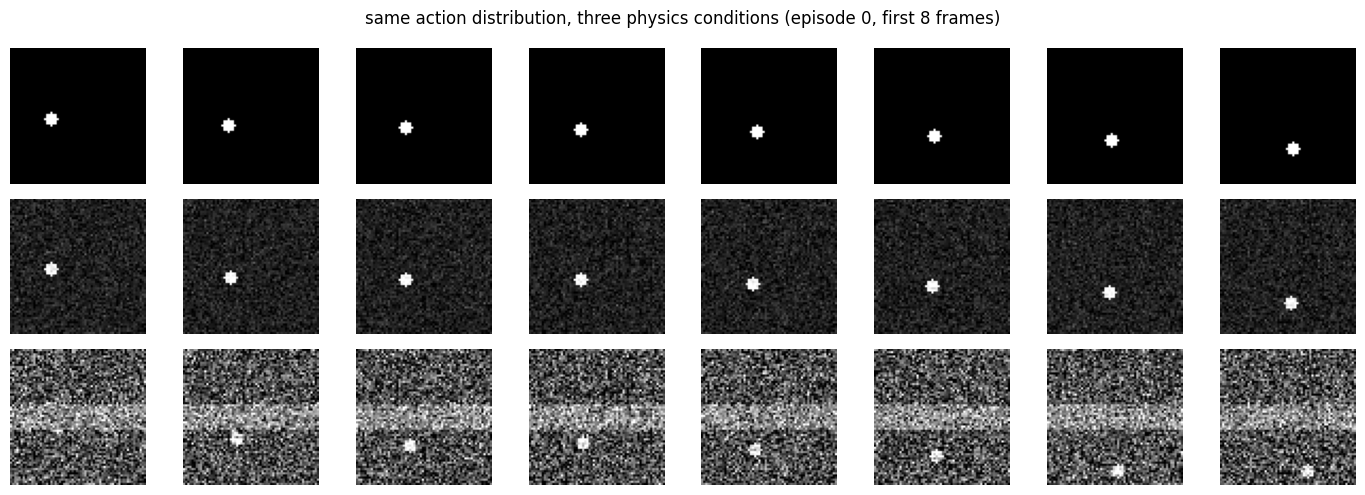

In [2]:
SIZE, DT = 64, 0.1

CONDITIONS = {
    "ID":     dict(speed=1.0, friction=0.95, bounce=0.9,  obs_noise=0.0,  background=0.0,  occlude=False),
    "Mild":   dict(speed=1.5, friction=0.95, bounce=0.9,  obs_noise=0.08, background=0.12, occlude=False),
    "Strong": dict(speed=3.0, friction=1.05, bounce=0.15, obs_noise=0.25, background=0.30, occlude=True),
}

class BallWorld:
    # 可参数化的弹球世界（Lab 0 的精简版）：白球 + 可选背景 / 噪声 / 遮挡
    def __init__(self, speed=1.0, friction=0.95, bounce=0.9,
                 obs_noise=0.0, background=0.0, occlude=False, seed=0):
        self.speed, self.friction, self.bounce = speed, friction, bounce
        self.obs_noise, self.background, self.occlude = obs_noise, background, occlude
        self.rng = np.random.default_rng(seed)
        self.state = None                       # (x, y, vx, vy)，归一化坐标

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        x, y = self.rng.uniform(0.15, 0.85, size=2)
        vx, vy = self.rng.uniform(-0.5, 0.5, size=2)
        self.state = np.array([x, y, vx, vy])
        return self.render()

    def step(self, a):
        x, y, vx, vy = self.state
        vx = (vx + 2.0 * self.speed * a[0] * DT) * self.friction
        vy = (vy + 2.0 * self.speed * a[1] * DT) * self.friction
        x, y = x + vx * DT, y + vy * DT
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce
        self.state = np.array([x, y, vx, vy])
        return self.render()

    def render(self):
        img = np.full((SIZE, SIZE), self.background, dtype=np.float32)
        px = int(np.clip(self.state[0], 0, 1) * (SIZE - 1))
        py = int(np.clip(self.state[1], 0, 1) * (SIZE - 1))
        yy, xx = np.mgrid[0:SIZE, 0:SIZE]
        img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = 1.0
        if self.occlude:                        # 静态遮挡条：训练分布中从未出现
            img[26:38, :] = min(self.background + 0.25, 1.0)
        if self.obs_noise > 0:
            img = img + self.rng.normal(0, self.obs_noise, img.shape)
        return np.clip(img, 0, 1).astype(np.float32)

def simulate_dataset(cond="ID", n_ep=100, ep_len=20, seed=0):
    params = CONDITIONS[cond] if isinstance(cond, str) else cond
    rng = np.random.default_rng(seed)
    world = BallWorld(**params, seed=seed)
    frames, actions, positions, ep_ids = [], [], [], []
    for ep in range(n_ep):
        world.reset(seed=seed * 1000 + ep)
        for t in range(ep_len):
            a = rng.integers(-1, 2, size=2).astype(np.float32)   # a ∈ {-1,0,1}²
            frames.append(world.step(a))
            actions.append(a)
            positions.append(world.state[:2].copy())
            ep_ids.append(ep)
    return dict(frames=np.stack(frames), actions=np.stack(actions),
                positions=np.stack(positions), ep_ids=np.array(ep_ids))

# 训练数据只用 ID；三种条件各生成一份评估数据（同样的动作分布，不同的物理）
data_id = simulate_dataset("ID", n_ep=100, ep_len=20, seed=0)
eval_data = {c: simulate_dataset(c, n_ep=40, ep_len=16, seed=100) for c in CONDITIONS}
print("train (ID):", data_id["frames"].shape, "| eval per condition:", eval_data["ID"]["frames"].shape)

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for row, cond in enumerate(CONDITIONS):
    for col in range(8):
        axes[row, col].imshow(eval_data[cond]["frames"][col], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cond, rotation=0, labelpad=35, fontsize=11)
plt.suptitle("same action distribution, three physics conditions (episode 0, first 8 frames)")
plt.tight_layout()
plt.show()

## 4. Build the Model：Encoder → Dynamics → Decoder

**Why this architecture:** 与 Lab 2 完全相同 —— ConvEncoder 把 64×64 图像压成 `z ∈ R^16`，
MLP dynamics 学残差转移 `(z_t, a_t) → ẑ_{t+1}`，ConvDecoder 把 latent 解回图像。
这正是 Dreamer / RSSM 类模型的最小骨架；本 lab 关心的是它的**评估**，不是它的结构。

In [3]:
Z_DIM, A_DIM = 16, 2

class Encoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU(),   # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),  # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),  # 16 -> 8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, x):
        return self.net(x)

class Dynamics(nn.Module):
    def __init__(self, z_dim=Z_DIM, a_dim=A_DIM, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + a_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, z_dim),
        )

    def forward(self, z, a):
        return z + self.net(torch.cat([z, a], dim=-1))  # residual transition

class Decoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(z_dim, 128), nn.ReLU(), nn.Linear(128, 64 * 8 * 8), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),  # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),  # 16 -> 32
            nn.ConvTranspose2d(16, 1, 4, 2, 1),              # 32 -> 64, raw logits
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 64, 8, 8))  # logits; sigmoid for display only

enc, dyn, dec = Encoder(), Dynamics(), Decoder()
n_params = sum(p.numel() for m in (enc, dyn, dec) for p in m.parameters())
print(f"parameters: {n_params:,}  (tiny — CPU-friendly)")

parameters: 1,160,641  (tiny — CPU-friendly)


## 5. Train（只用 ID 数据）

**Why these two losses:** reconstruction（BCE）让 encoder 学到可解码的表征；one-step latent prediction（MSE，stop-gradient）让 dynamics 对齐 encoder 的几何。**模型从头到尾只见过 ID 物理** —— 之后所有的 Mild / Strong 数据都是它的"未知世界"。

1900 valid ID transitions


step  200/800  recon-BCE 0.2530  latent-pred(norm) 0.0000


step  400/800  recon-BCE 0.0166  latent-pred(norm) 0.0970


step  600/800  recon-BCE 0.0082  latent-pred(norm) 0.0958


step  800/800  recon-BCE 0.0070  latent-pred(norm) 0.1098
trained in 108.5s on CPU (ID data only)


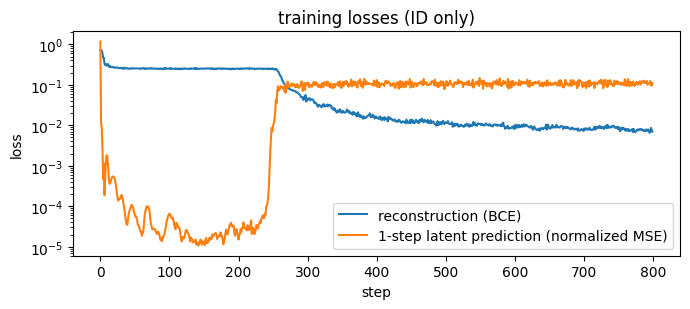

In [4]:
def prep(data):
    imgs = torch.from_numpy(data["frames"]).unsqueeze(1)      # (N, 1, 64, 64)
    acts = torch.from_numpy(data["actions"])                  # (N, 2)
    valid = np.where(data["ep_ids"][:-1] == data["ep_ids"][1:])[0]  # episode 内相邻帧
    return imgs, acts, valid

imgs_id, acts_id, valid_id = prep(data_id)
print(f"{len(valid_id)} valid ID transitions")

params = list(enc.parameters()) + list(dyn.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(params, lr=3e-3)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(10.0))  # ball pixels are rare positives
mse = nn.MSELoss()

BATCH, STEPS = 64, 800
rng = np.random.default_rng(0)
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = torch.from_numpy(rng.choice(valid_id, size=BATCH, replace=False))
    x0, x1, a = imgs_id[idx], imgs_id[idx + 1], acts_id[idx]

    z0 = enc(x0)
    z1_target = enc(x1).detach()                 # stop-gradient target
    z1_pred = dyn(z0.detach(), a)                # enc is shaped by recon only

    loss_recon = bce(dec(z0), x0)
    loss_pred = mse(z1_pred, z1_target)
    loss = loss_recon + loss_pred

    opt.zero_grad(); loss.backward(); opt.step()
    losses.append((loss_recon.item(), loss_pred.item() / (z1_target.var().item() + 1e-8)))
    if (step + 1) % 200 == 0:
        print(f"step {step+1:4d}/{STEPS}  recon-BCE {loss_recon.item():.4f}  latent-pred(norm) {losses[-1][1]:.4f}")

print(f"trained in {time.time() - t0:.1f}s on CPU (ID data only)")

losses = np.array(losses)
plt.figure(figsize=(7, 3.2))
plt.plot(losses[:, 0], label="reconstruction (BCE)")
plt.plot(losses[:, 1], label="1-step latent prediction (normalized MSE)")
plt.xlabel("step"); plt.ylabel("loss"); plt.yscale("log")
plt.title("training losses (ID only)"); plt.legend(); plt.tight_layout(); plt.show()

## 6. Visualize：ID 上的健康检查

**Why check ID first:** 评估 OOD 退化之前，先确认模型在训练分布内是合格的 —— reconstruction 清晰、one-step 预测对准。否则 OOD 误差无法归因于 distribution shift。

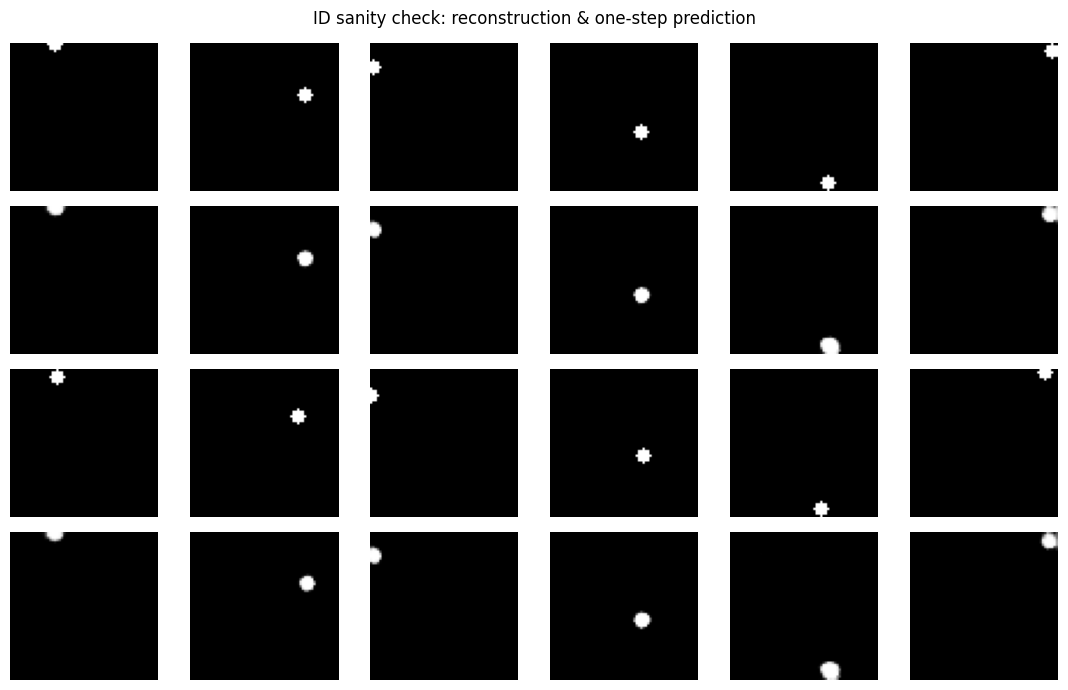

In [5]:
enc.eval(); dyn.eval(); dec.eval()
rng = np.random.default_rng(1)
idx = torch.from_numpy(rng.choice(valid_id, size=6, replace=False))

with torch.no_grad():
    z0 = enc(imgs_id[idx])
    recon = torch.sigmoid(dec(z0))
    z1_pred = dyn(z0, acts_id[idx])
    pred_next = torch.sigmoid(dec(z1_pred))

fig, axes = plt.subplots(4, 6, figsize=(11, 7))
rows = [imgs_id[idx, 0], recon[:, 0], imgs_id[idx + 1, 0], pred_next[:, 0]]
titles = ["input $x_t$", "reconstruction", "true $x_{t+1}$", "predicted $\hat{x}_{t+1}$"]
for r, (row_imgs, title) in enumerate(zip(rows, titles)):
    for c in range(6):
        axes[r, c].imshow(row_imgs[c], cmap="gray", vmin=0, vmax=1)
        axes[r, c].axis("off")
    axes[r, 0].set_ylabel(title, rotation=0, labelpad=95, fontsize=9)
plt.suptitle("ID sanity check: reconstruction & one-step prediction")
plt.tight_layout(); plt.show()

## 7. Evaluate I — one-step error：ID vs Mild vs Strong

第一个问题：**one-step error 对 distribution shift 有多敏感？** 对每份评估数据，计算真实相邻帧上的 latent prediction MSE 与解码后的 pixel MSE。

注意 Mild/Strong 的输入帧本身也 OOD（噪声、背景、遮挡），所以这里同时考验 encoder 与 dynamics 的 robustness。

ID       one-step latent MSE 57.8276   pixel MSE 0.00872
Mild     one-step latent MSE 67.1142   pixel MSE 0.02714
Strong   one-step latent MSE 396.7531   pixel MSE 0.19205


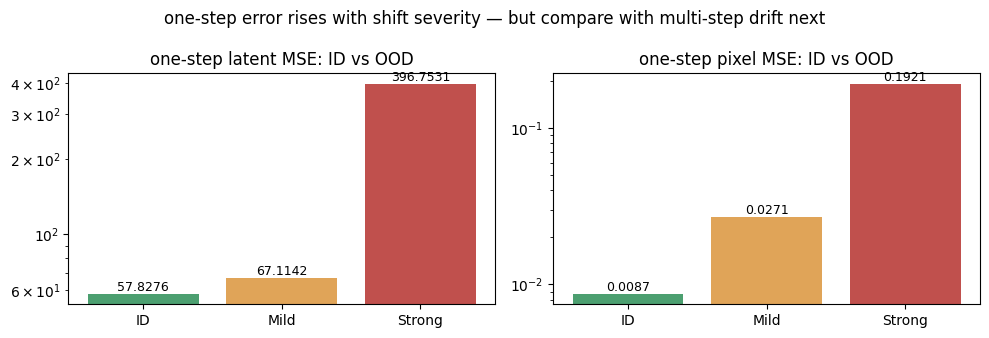

In [6]:
def one_step_eval(data):
    imgs, acts, valid = prep(data)
    with torch.no_grad():
        z0, z1 = enc(imgs[valid]), enc(imgs[valid + 1])
        z1_pred = dyn(z0, acts[valid])
        latent_err = ((z1_pred - z1) ** 2).mean(dim=1).numpy()
        pixel_err = ((torch.sigmoid(dec(z1_pred)) - imgs[valid + 1]) ** 2).mean(dim=(1, 2, 3)).numpy()
    return latent_err, pixel_err

one_step = {c: one_step_eval(eval_data[c]) for c in CONDITIONS}
for c in CONDITIONS:
    print(f"{c:7s}  one-step latent MSE {one_step[c][0].mean():.4f}   pixel MSE {one_step[c][1].mean():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, k, name in zip(axes, [0, 1], ["latent MSE", "pixel MSE"]):
    means = [one_step[c][k].mean() for c in CONDITIONS]
    bars = ax.bar(CONDITIONS.keys(), means, color=["#4c9f70", "#e0a458", "#c0504d"])
    ax.set_title(f"one-step {name}: ID vs OOD"); ax.set_yscale("log")
    for b, m in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, m, f"{m:.4f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("one-step error rises with shift severity — but compare with multi-step drift next")
plt.tight_layout(); plt.show()

## 8. Evaluate II — multi-step rollout drift（核心教学点）

现在做部署时真正发生的事：**open-loop rollout** —— 只给初始帧与动作序列，模型每步吃自己的预测。
每条曲线是 48 条 rollout 的均值（阴影 = SEM）。

**关于指标的选择：** pixel MSE 会**饱和** —— 球只有 ~30 像素，预测位置偏出球径后误差就不再增长，会掩盖 drift。
我们把预测翻译成物理单位：对解码出的预测帧做 **soft-argmax**（带温度的 softmax 质心，对背景偏移与亮度变化稳健），
与隐藏真值位置算 **position error**（L2，归一化坐标）。它随 horizon 平滑增长，能清晰暴露 compounding。

**观察重点：** ID 在 step-1 误差很小（~0.06），12 步后增长约 7 倍 —— "one-step 看起来不错但 multi-step 逐渐崩溃"；
OOD 条件从 step-1 就显著更差，并迅速冲向 **chance level**（~0.5，随机猜测的期望误差）。
三条曲线最终在 chance level 汇合：长期 open-loop 下任何模型都会退化，区别只在于**多快**。
这就是 **compounding error**：单步误差被下一步当作输入放大，OOD 物理下放大得更快。

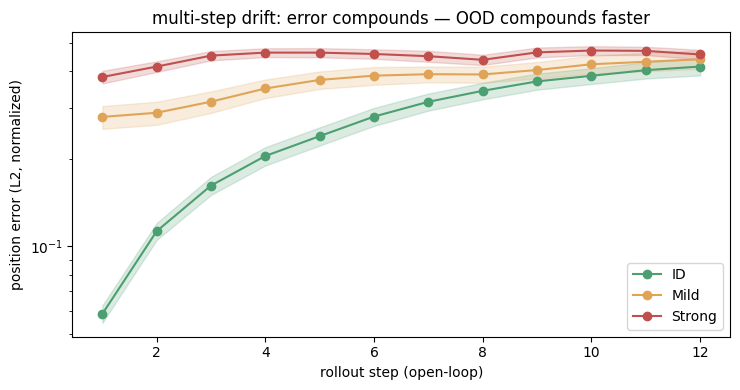

ID       position err  step-1 0.0586 -> step-12 0.4154  (growth ×7.1)   | pixel MSE step-1 0.0094 -> step-12 0.0112 (saturates)
Mild     position err  step-1 0.2787 -> step-12 0.4399  (growth ×1.6)   | pixel MSE step-1 0.0272 -> step-12 0.0278 (saturates)
Strong   position err  step-1 0.3824 -> step-12 0.4571  (growth ×1.2)   | pixel MSE step-1 0.1919 -> step-12 0.1926 (saturates)


In [7]:
HORIZON = 12

def soft_position(img, T=0.1):
    # soft-argmax：预测帧最亮区域的加权质心 ≈ 模型「认为」球的位置，(B,1,H,W) -> (B,2)
    b = img.shape[0]
    w = torch.softmax(img.reshape(b, -1) / T, dim=1)
    yy, xx = torch.meshgrid(torch.linspace(0, 1, SIZE), torch.linspace(0, 1, SIZE), indexing="ij")
    return torch.stack([(w * xx.reshape(-1)).sum(1), (w * yy.reshape(-1)).sum(1)], dim=1)

def rollout_eval(data, horizon=HORIZON, n_roll=48, seed=0):
    imgs, acts, _ = prep(data)
    pos = torch.from_numpy(data["positions"]).float()            # 隐藏真值位置（评估专用）
    cand = np.where(data["ep_ids"][:-horizon] == data["ep_ids"][horizon:])[0]
    starts = np.random.default_rng(seed).choice(cand, size=min(n_roll, len(cand)), replace=False)
    pos_errs, pix_errs = np.zeros((len(starts), horizon)), np.zeros((len(starts), horizon))
    with torch.no_grad():
        for si, s in enumerate(starts):
            z = enc(imgs[s:s + 1])
            for t in range(horizon):
                z = dyn(z, acts[s + t:s + t + 1])                  # 吃自己的预测
                img_hat = torch.sigmoid(dec(z))
                pos_errs[si, t] = torch.linalg.norm(soft_position(img_hat)[0] - pos[s + t + 1]).item()
                pix_errs[si, t] = ((img_hat - imgs[s + t + 1]) ** 2).mean().item()
    return starts, pos_errs, pix_errs

rollouts = {c: rollout_eval(eval_data[c]) for c in CONDITIONS}

plt.figure(figsize=(7.5, 4))
for c, color in zip(CONDITIONS, ["#4c9f70", "#e0a458", "#c0504d"]):
    m = rollouts[c][1]
    mu, se = m.mean(0), m.std(0) / np.sqrt(len(m))
    plt.plot(range(1, HORIZON + 1), mu, "o-", color=color, label=c)
    plt.fill_between(range(1, HORIZON + 1), mu - se, mu + se, color=color, alpha=0.2)
plt.xlabel("rollout step (open-loop)"); plt.ylabel("position error (L2, normalized)")
plt.yscale("log")
plt.title("multi-step drift: error compounds — OOD compounds faster")
plt.legend(); plt.tight_layout(); plt.show()

for c in CONDITIONS:
    p, x = rollouts[c][1], rollouts[c][2]
    print(f"{c:7s}  position err  step-1 {p[:, 0].mean():.4f} -> step-{HORIZON} {p[:, -1].mean():.4f}  (growth ×{p[:, -1].mean() / p[:, 0].mean():.1f})"
          f"   | pixel MSE step-1 {x[:, 0].mean():.4f} -> step-{HORIZON} {x[:, -1].mean():.4f} (saturates)")

## 9. Evaluate III — uncertainty proxy：模型「知道」自己不行吗？

部署时我们拿不到真实误差，需要一个 **uncertainty proxy** 来决定是否信任预测。最便宜的方案是 **ensemble disagreement**（PETS / Deep Ensembles 思路）：训练 K 个不同初始化的 dynamics net，预测分歧大 = 不可信。

下面在 ID 数据的 latent 上快速训练 K=5 个 dynamics（秒级），然后检验：**disagreement 与真实误差的相关性有多强？**

ensemble of 5 dynamics nets trained (last loss 43.99822)


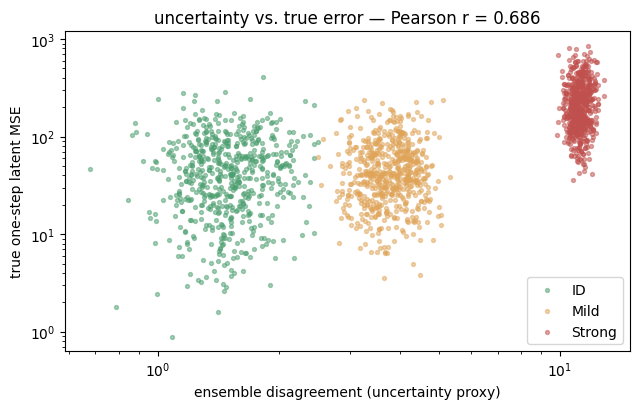

Pearson r (disagreement vs true error, pooled over 3 conditions) = 0.686
ID       mean disagreement 1.51862   mean true error 55.13338
Mild     mean disagreement 3.78691   mean true error 53.34560
Strong   mean disagreement 11.19473   mean true error 237.69089
=> disagreement 随 shift 单调上升，并与真实误差正相关：一个廉价但有用的 OOD 报警器。


In [8]:
K = 5
with torch.no_grad():
    Z0 = enc(imgs_id[valid_id]); Z1 = enc(imgs_id[valid_id + 1]); A0 = acts_id[valid_id]

ensemble = []
for k in range(K):
    torch.manual_seed(100 + k)
    net = Dynamics()
    opt_k = torch.optim.Adam(net.parameters(), lr=3e-3)
    for step in range(600):
        idx = torch.randint(0, len(Z0), (256,))
        loss_k = mse(net(Z0[idx], A0[idx]), Z1[idx])
        opt_k.zero_grad(); loss_k.backward(); opt_k.step()
    ensemble.append(net.eval())
print(f"ensemble of {K} dynamics nets trained (last loss {loss_k.item():.5f})")

def disagreement_eval(data):
    imgs, acts, valid = prep(data)
    with torch.no_grad():
        z0, z1 = enc(imgs[valid]), enc(imgs[valid + 1])
        preds = torch.stack([m(z0, acts[valid]) for m in ensemble])  # (K, N, z)
        true_err = ((preds.mean(0) - z1) ** 2).mean(dim=1).numpy()   # ensemble-mean 的真实误差
        dis = preds.std(dim=0).mean(dim=1).numpy()                   # ensemble disagreement
    return dis, true_err

unc = {c: disagreement_eval(eval_data[c]) for c in CONDITIONS}
all_dis = np.concatenate([unc[c][0] for c in CONDITIONS])
all_err = np.concatenate([unc[c][1] for c in CONDITIONS])
r = np.corrcoef(all_dis, all_err)[0, 1]

plt.figure(figsize=(6.5, 4.2))
for c, color in zip(CONDITIONS, ["#4c9f70", "#e0a458", "#c0504d"]):
    plt.scatter(unc[c][0], unc[c][1], s=8, alpha=0.5, color=color, label=c)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("ensemble disagreement (uncertainty proxy)")
plt.ylabel("true one-step latent MSE")
plt.title(f"uncertainty vs. true error — Pearson r = {r:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Pearson r (disagreement vs true error, pooled over 3 conditions) = {r:.3f}")
for c in CONDITIONS:
    print(f"{c:7s}  mean disagreement {unc[c][0].mean():.5f}   mean true error {unc[c][1].mean():.5f}")
print("=> disagreement 随 shift 单调上升，并与真实误差正相关：一个廉价但有用的 OOD 报警器。")

## 10. Evaluate IV — prediction error → planning error → policy failure

最后把链条闭合：**用 ID 训练的模型做 planning，在 OOD 物理上执行。** 任务：把球开到目标位置 ★。
Planner 是最简单的 **random shooting**（~12 行）：采样数百条候选动作序列 → 用模型想象每条的未来 → 选"想象中"最接近目标的序列；执行时采用 **receding-horizon（MPC 风格）**：每步重新编码真实帧、重新规划、只执行第一个动作。

**关键观察：** 模型的想象基于 ID 物理（它不知道世界变了）；ID 下 MPC 基本到达 ★，Strong OOD 下每一步都 overshoot ×3、被粘滞墙吸住 —— **policy failure**。

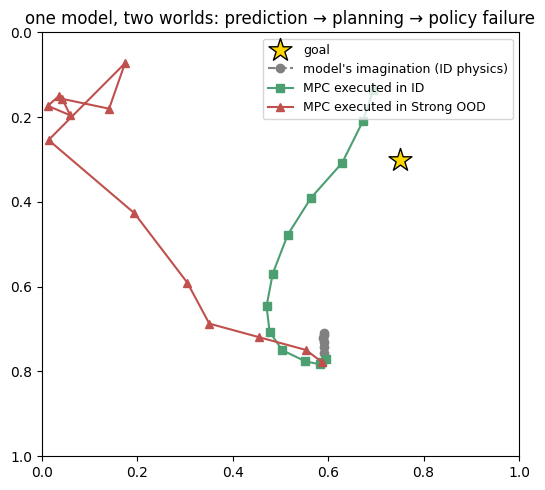

final distance to goal — imagined 0.438 | MPC in ID 0.173 | MPC in Strong OOD 0.729


In [9]:
GOAL = np.array([0.75, 0.30])

def random_shooting(z0, horizon=6, n_samples=768, seed=0):
    cand = torch.randint(-1, 2, (n_samples, horizon, 2),
                         generator=torch.Generator().manual_seed(seed)).float()
    z, cost = z0.repeat(n_samples, 1), torch.zeros(n_samples)
    goal_t = torch.tensor(GOAL, dtype=torch.float32)
    with torch.no_grad():
        for t in range(horizon):
            z = dyn(z, cand[:, t])                                   # imagine one step
            d2 = ((soft_position(torch.sigmoid(dec(z))) - goal_t) ** 2).sum(dim=1)  # 模型「认为」球在哪
            cost += d2 if t < horizon - 1 else 4 * d2                # 额外奖励最终停在目标
    return cand[cost.argmin()]                                       # best imagined sequence

def run_mpc(cond, seed, n_replan=12, horizon=6, n_samples=768):
    world = BallWorld(**CONDITIONS[cond], seed=seed)
    frame = world.reset(seed=seed)
    traj, first_imagined = [world.state[:2].copy()], None
    for t in range(n_replan):
        with torch.no_grad():
            z0 = enc(torch.from_numpy(frame)[None, None])
        plan = random_shooting(z0, horizon, n_samples, seed=seed + t)
        if first_imagined is None:                                   # 存档第一次规划的想象轨迹
            with torch.no_grad():
                z, imagined = z0.clone(), [traj[0]]
                for k in range(horizon):
                    z = dyn(z, plan[k:k + 1])
                    imagined.append(soft_position(torch.sigmoid(dec(z))).numpy()[0])
            first_imagined = np.array(imagined)
        frame = world.step(plan[0].numpy())                          # receding horizon: 只执行第一步
        traj.append(world.state[:2].copy())
    return np.array(traj), first_imagined

SEED_PLAN = 7
traj_id, imagined = run_mpc("ID", SEED_PLAN)
traj_strong, _ = run_mpc("Strong", SEED_PLAN)   # 同一个模型、同一个起点、同一个 planner

plt.figure(figsize=(5.5, 5))
plt.scatter(*GOAL, marker="*", s=300, c="gold", edgecolors="k", label="goal", zorder=5)
plt.plot(imagined[:, 0], imagined[:, 1], "o--", c="gray", label="model's imagination (ID physics)")
plt.plot(traj_id[:, 0], traj_id[:, 1], "s-", c="#4c9f70", label="MPC executed in ID")
plt.plot(traj_strong[:, 0], traj_strong[:, 1], "^-", c="#c0504d", label="MPC executed in Strong OOD")
plt.xlim(0, 1); plt.ylim(1, 0); plt.legend(loc="upper right", fontsize=9)
plt.title("one model, two worlds: prediction → planning → policy failure")
plt.tight_layout()
plt.savefig("assets/failure_gallery/planning_failure.png", dpi=110, bbox_inches="tight")
plt.show()

d = lambda traj: np.linalg.norm(traj[-1] - GOAL)
print(f"final distance to goal — imagined {d(imagined):.3f} | MPC in ID {d(traj_id):.3f} | MPC in Strong OOD {d(traj_strong):.3f}")

## 11. Failure Gallery：把失败存档

**Why:** 部署前的模型审计不能只留一条曲线 —— 把**最典型的失败案例**（误差最大的 rollout、规划失败的轨迹）连同 caption 存进 `assets/failure_gallery/`，下次模型更新后直接对比。下面的代码自动挑选每种条件下最终步误差最大的 rollout（上排真实帧 / 下排模型 dream），保存 PNG 拼图与 caption 文件。

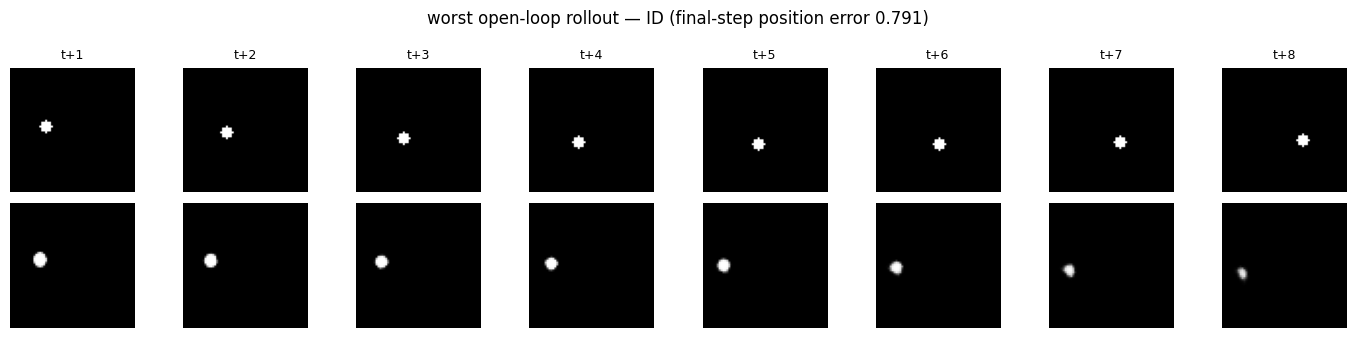

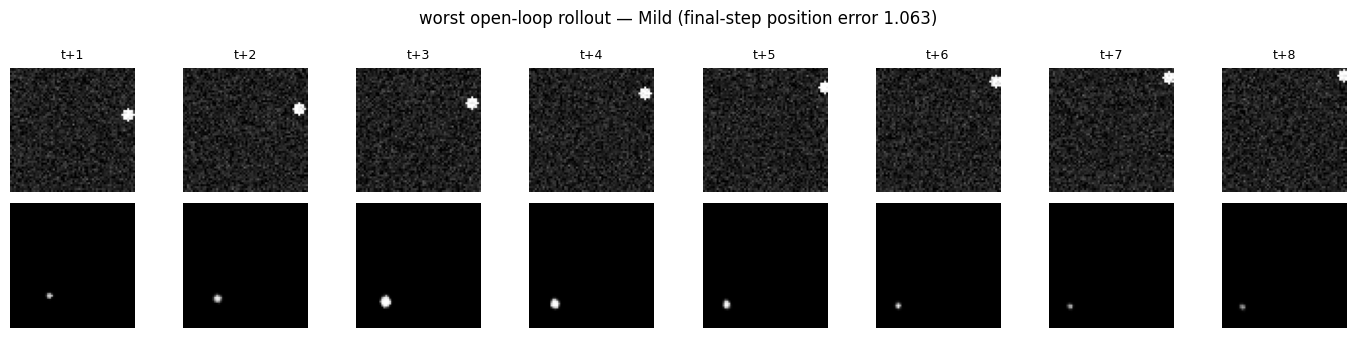

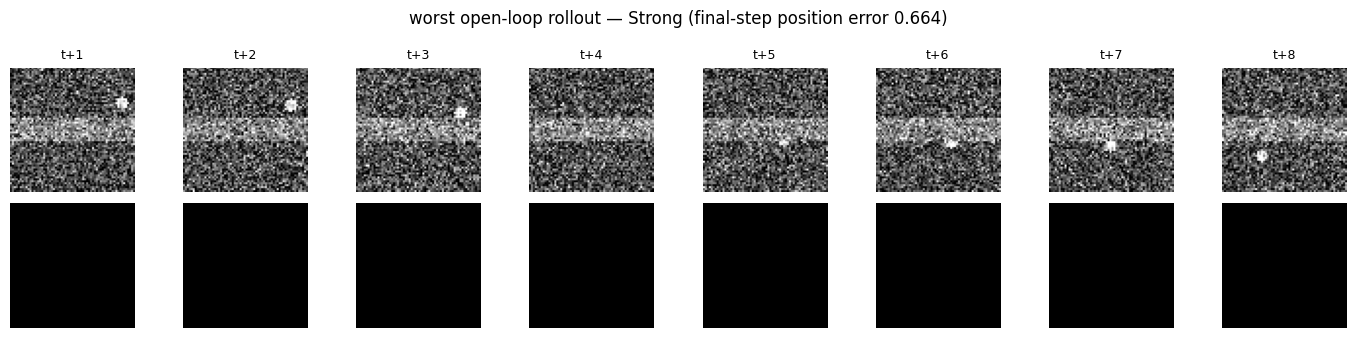

failure_gallery 内容：
   captions.txt
   planning_failure.png
   rollout_id.png
   rollout_mild.png
   rollout_strong.png


In [10]:
GAL = "assets/failure_gallery"
SHOW = 8
captions = []

for cond in CONDITIONS:
    starts, pos_errs, _ = rollouts[cond]
    worst = starts[np.argmax(pos_errs[:, -1])]       # 最终步位置误差最大的 rollout
    imgs_c, acts_c, _ = prep(eval_data[cond])
    with torch.no_grad():
        z = enc(imgs_c[worst:worst + 1])
        dream = []
        for t in range(SHOW):
            z = dyn(z, acts_c[worst + t:worst + t + 1])
            dream.append(torch.sigmoid(dec(z))[0, 0].numpy())
    truth = [imgs_c[worst + t + 1, 0].numpy() for t in range(SHOW)]

    fig, axes = plt.subplots(2, SHOW, figsize=(14, 3.4))
    for t in range(SHOW):
        axes[0, t].imshow(truth[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].imshow(dream[t], cmap="gray", vmin=0, vmax=1)
        for r in range(2):
            axes[r, t].axis("off")
        axes[0, t].set_title(f"t+{t + 1}", fontsize=9)
    axes[0, 0].set_ylabel("truth", rotation=0, labelpad=30)
    axes[1, 0].set_ylabel("dream", rotation=0, labelpad=30)
    plt.suptitle(f"worst open-loop rollout — {cond} (final-step position error {pos_errs[:, -1].max():.3f})")
    plt.tight_layout()
    fname = f"rollout_{cond.lower()}.png"
    plt.savefig(os.path.join(GAL, fname), dpi=110, bbox_inches="tight")
    plt.show()
    captions.append(f"{fname:22s} — {cond} 条件最终步位置误差最大的 open-loop rollout（上排真实帧，下排模型 dream，final position error {pos_errs[:, -1].max():.3f}）")

captions.append("planning_failure.png   — 同一 ID 模型 + random shooting 的计划轨迹（想象）vs 在 ID / Strong OOD 真实执行的轨迹：OOD 下 policy failure")
with open(os.path.join(GAL, "captions.txt"), "w") as f:
    f.write("Lab 10 Failure Gallery — 自动生成\n" + "=" * 60 + "\n" + "\n".join(captions) + "\n")

print("failure_gallery 内容：")
for f_ in sorted(os.listdir(GAL)):
    print("  ", f_)

## 12. Experiment：漂移速度扫描（speed sweep）

**Guided knob:** 只改一个参数 —— `speed` 从 ×1.0 扫到 ×3.0（其余保持 ID），对比 **one-step** 与 **8-step rollout** 的 position error（log 刻度；虚线 = 随机猜测的期望误差 ≈ 0.52）。

你会看到：one-step error 即使到 ×3 也只有 ~0.13，单看它会以为模型"还不错"；但 8-step rollout **在 ID 下就已接近 chance level** —— multi-step 崩溃并不需要 OOD，OOD 只是让它来得更早、更彻底。

speed ×1.0   one-step position err 0.0530   8-step rollout position err 0.3697


speed ×1.5   one-step position err 0.0809   8-step rollout position err 0.4093


speed ×2.0   one-step position err 0.0853   8-step rollout position err 0.4411


speed ×2.5   one-step position err 0.1027   8-step rollout position err 0.4756


speed ×3.0   one-step position err 0.1262   8-step rollout position err 0.4635


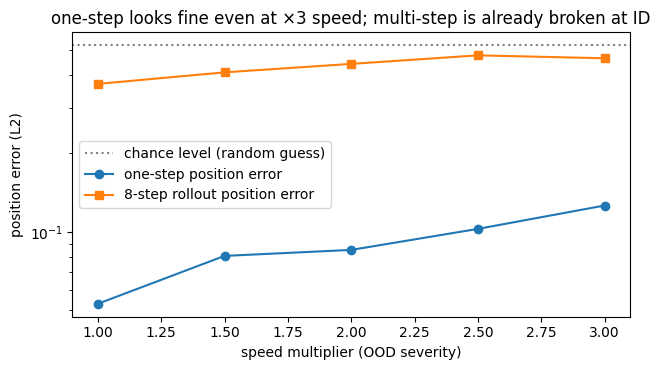

In [11]:
def one_step_pos_err(data):
    imgs, acts, valid = prep(data)
    pos = torch.from_numpy(data["positions"]).float()
    with torch.no_grad():
        pred = soft_position(torch.sigmoid(dec(dyn(enc(imgs[valid]), acts[valid]))))
        return torch.linalg.norm(pred - pos[valid + 1], dim=1).numpy()

sweep = [1.0, 1.5, 2.0, 2.5, 3.0]
curve_1step, curve_8step = [], []
for s in sweep:
    d_s = simulate_dataset(dict(speed=s, friction=0.95, bounce=0.9,
                                obs_noise=0.0, background=0.0, occlude=False),
                           n_ep=24, ep_len=14, seed=300 + int(s * 10))
    curve_1step.append(one_step_pos_err(d_s).mean())
    curve_8step.append(rollout_eval(d_s, horizon=8, n_roll=24)[1][:, -1].mean())
    print(f"speed ×{s:.1f}   one-step position err {curve_1step[-1]:.4f}   8-step rollout position err {curve_8step[-1]:.4f}")

plt.figure(figsize=(6.5, 3.8))
plt.axhline(0.52, ls=":", c="gray", label="chance level (random guess)")
plt.plot(sweep, curve_1step, "o-", label="one-step position error")
plt.plot(sweep, curve_8step, "s-", label="8-step rollout position error")
plt.yscale("log")
plt.xlabel("speed multiplier (OOD severity)"); plt.ylabel("position error (L2)")
plt.title("one-step looks fine even at ×3 speed; multi-step is already broken at ID")
plt.legend(); plt.tight_layout(); plt.show()

## 13. Questions（思考题）

1. **为什么 one-step error 在 Mild OOD 上只小幅上升，而 multi-step error 显著恶化？** 从"误差被当作下一步输入"的角度解释 compounding 机制。
2. **Uncertainty proxy 的盲区：** ensemble disagreement 在哪种 shift 下最可靠？如果 OOD 恰好落在所有 ensemble member 都"一致地错"的区域（例如系统性偏差），这个报警器会失效吗？
3. **Uncertainty-penalized planning：** 如果把 cost 改成 `distance + λ × ensemble disagreement`，planner 会避开模型不可靠的动作吗？你会怎么设计实验验证？
4. **设计一个能骗过当前 uncertainty proxy 的 OOD shift**（提示：从训练数据的对称性 / encoder 的不变性入手）。

## 14. Takeaways

- **One-step loss ≠ 模型质量。** 部署看的是 multi-step rollout：误差 compounding，曲线随 horizon 超线性增长，OOD 下增长更快。
- **受控 distribution shift 是最便宜的 robustness 实验。** 同一个模拟器，换一组物理参数（速度、摩擦、反弹、噪声、遮挡），就能分级评估 ID / Mild / Strong OOD。
- **Ensemble disagreement 是廉价有用的 uncertainty proxy**（与真实误差正相关），但它不保证 calibrated，也存在"一致地错"的盲区。
- **Prediction error → planning error → policy failure：** planner 基于模型的想象做决策，模型哪里错，planner 就往哪里撞。评估 world model 的终点必须是 downstream utility。
- **Failure Gallery 应当成为训练流水线的一部分：** 定量曲线 + 定性失败案例存档，才能在模型迭代时回答"它变好了吗"。
- 对应 CIS6280 L23 评估框架：accuracy → calibration → robustness → downstream utility，本 lab 走完了完整闭环。

**Next:** 更系统的做法 —— learned reward 下的 MPC/CEM、RSSM posterior correction 抗 drift、以及用 uncertainty 触发的人工接管（见 `/docs/scientist/12-ood-drift-evaluation`）。